In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("18-concrete_data.csv")

In [3]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [9]:
df.isna().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

array([[<Axes: title={'center': 'Cement'}>,
        <Axes: title={'center': 'Blast Furnace Slag'}>,
        <Axes: title={'center': 'Fly Ash'}>],
       [<Axes: title={'center': 'Water'}>,
        <Axes: title={'center': 'Superplasticizer'}>,
        <Axes: title={'center': 'Coarse Aggregate'}>],
       [<Axes: title={'center': 'Fine Aggregate'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Strength'}>]], dtype=object)

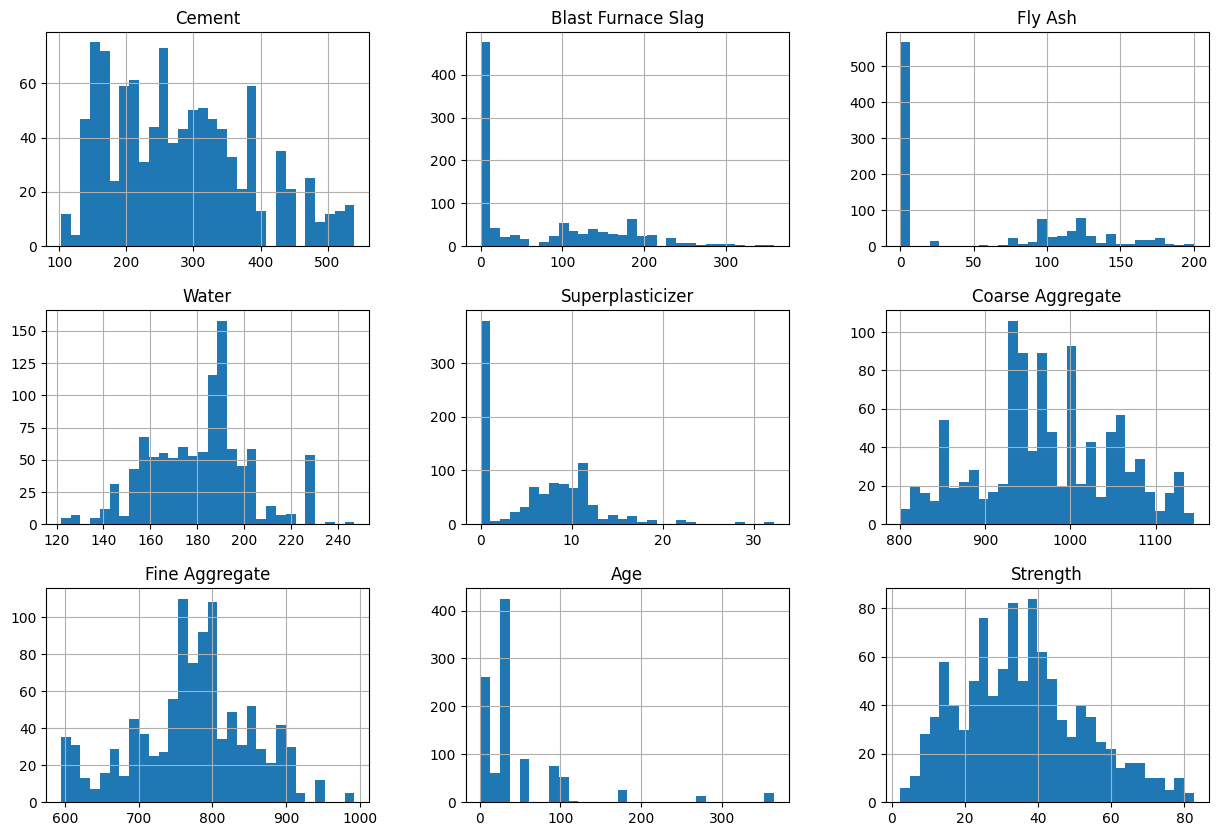

In [10]:
df.hist(figsize=(15, 10), bins=30)

In [11]:
df.duplicated().sum()

25

In [12]:
df[df.duplicated(keep=False)].sort_values(
    by=df.columns.tolist()
)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
801,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
809,252.0,0.0,0.0,185.0,0.0,1111.0,784.0,28,19.69
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30
106,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
111,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90
129,362.6,189.0,0.0,164.9,11.6,944.7,755.8,28,71.30


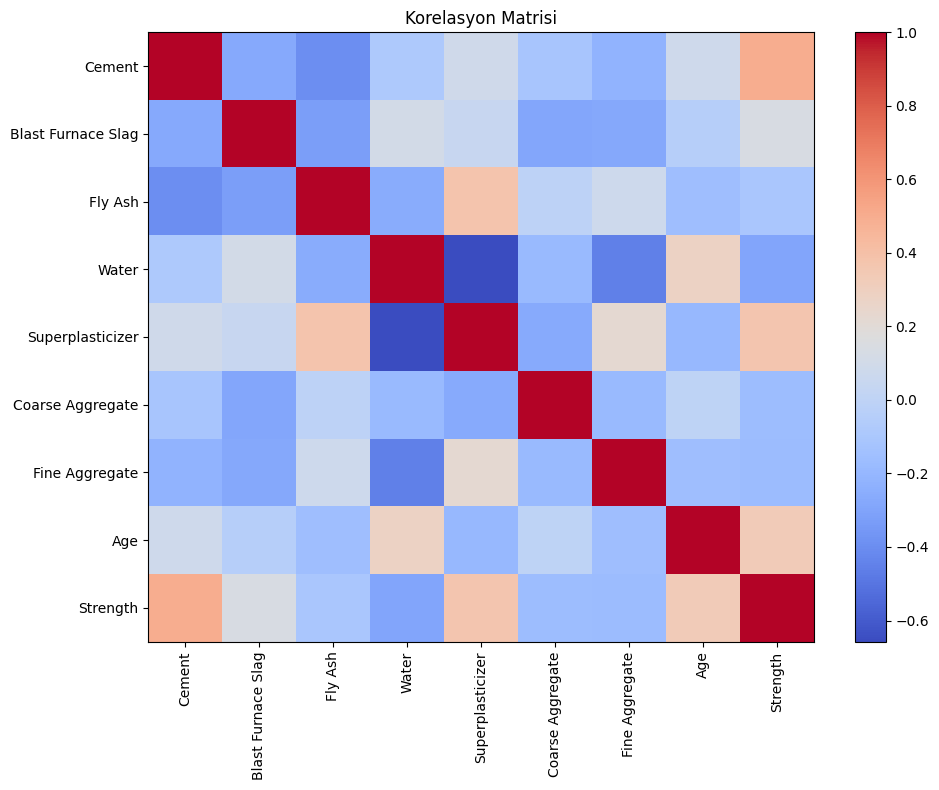

In [13]:
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

In [14]:
df.corr(numeric_only=True)["Strength"].sort_values(ascending=False)

Strength              1.000000
Cement                0.497832
Superplasticizer      0.366079
Age                   0.328873
Blast Furnace Slag    0.134829
Fly Ash              -0.105755
Coarse Aggregate     -0.164935
Fine Aggregate       -0.167241
Water                -0.289633
Name: Strength, dtype: float64

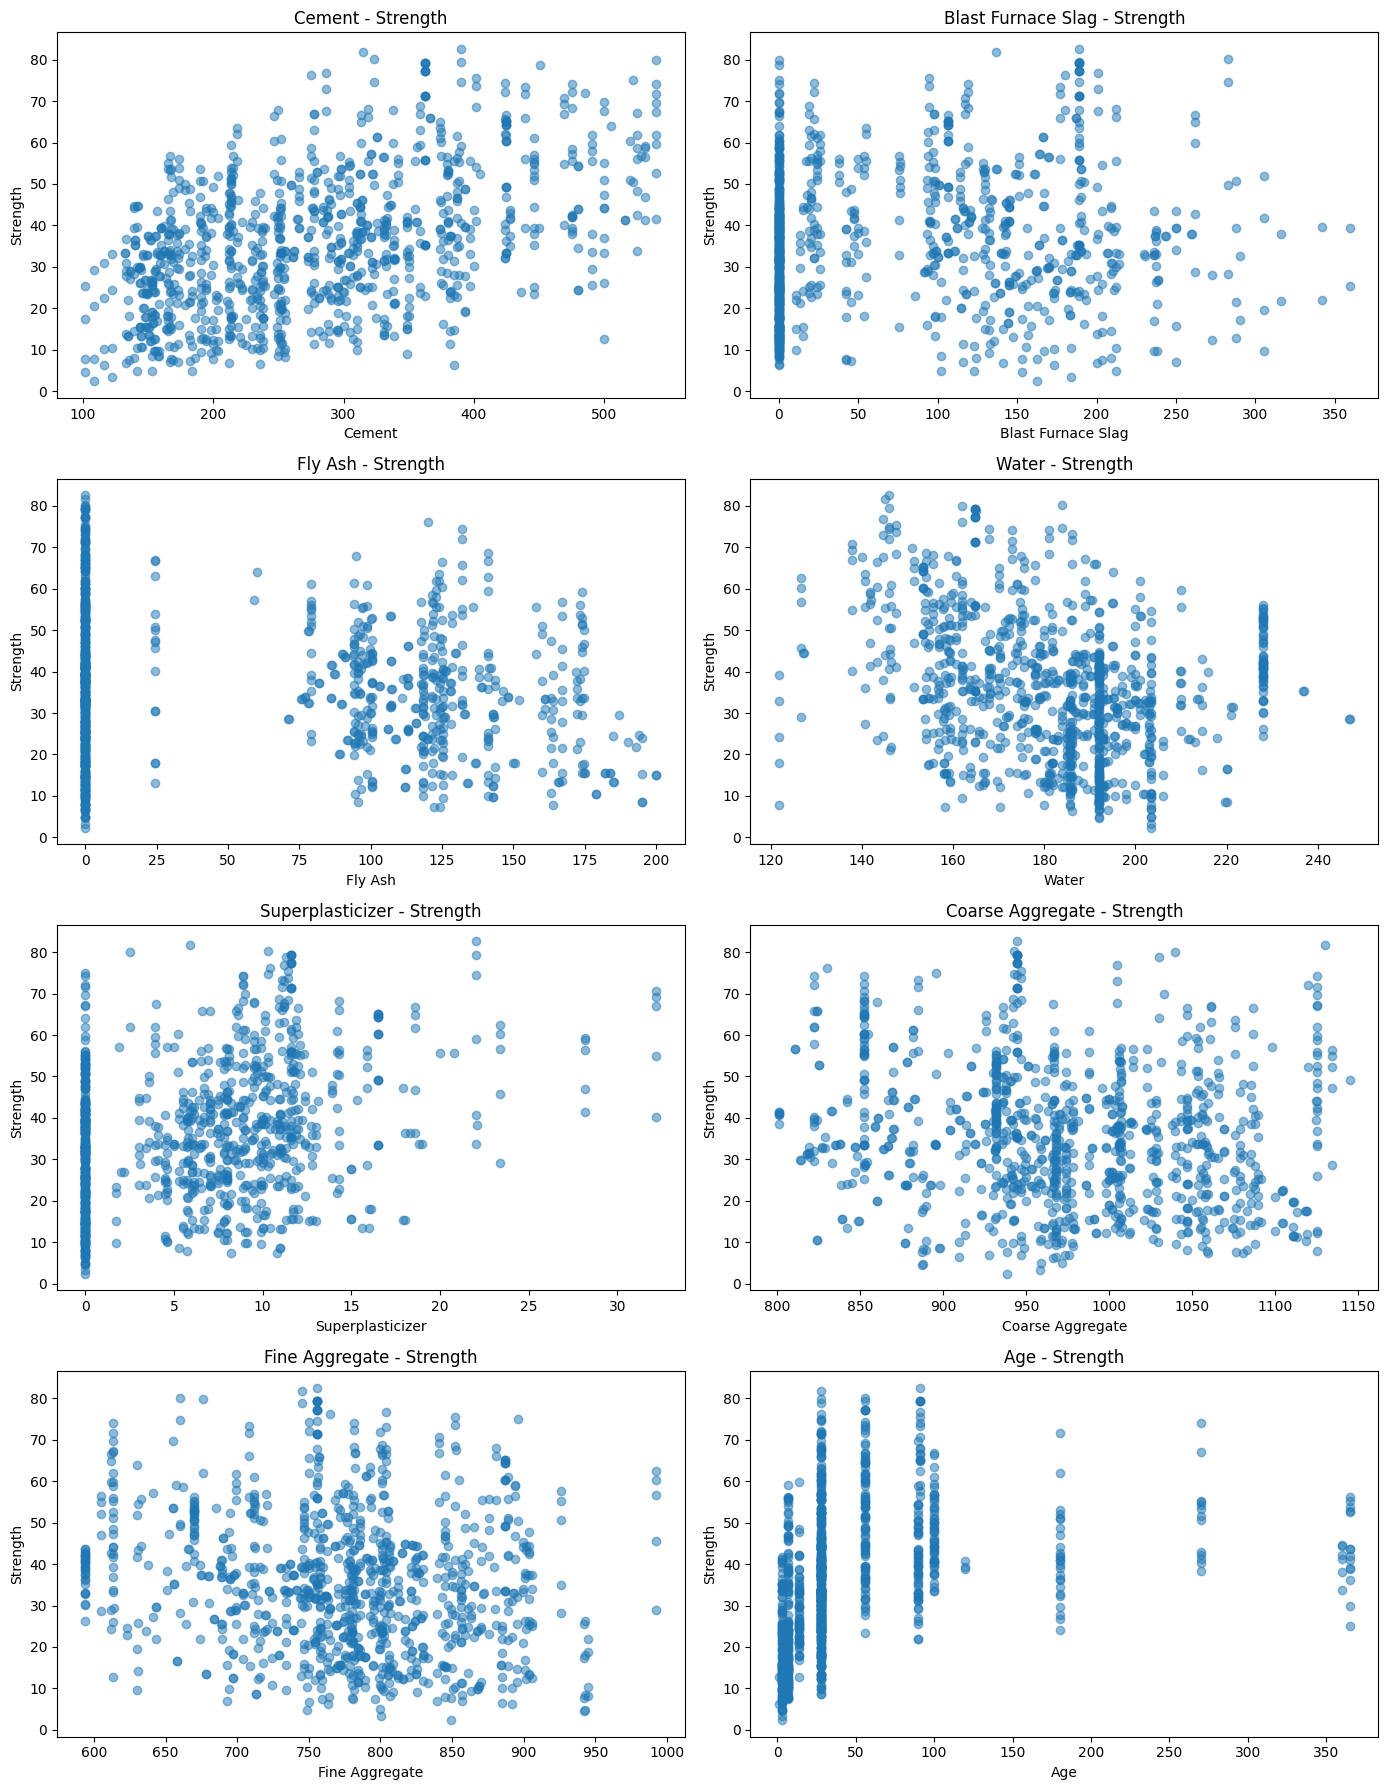

In [15]:
features = df.drop(columns="Strength").columns

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for index, column in enumerate(features):
    axes[index].scatter(
        df[column],
        df["Strength"],
        alpha=0.5
    )
    axes[index].set_title(f"{column} - Strength")
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Strength")

plt.tight_layout()
plt.show()

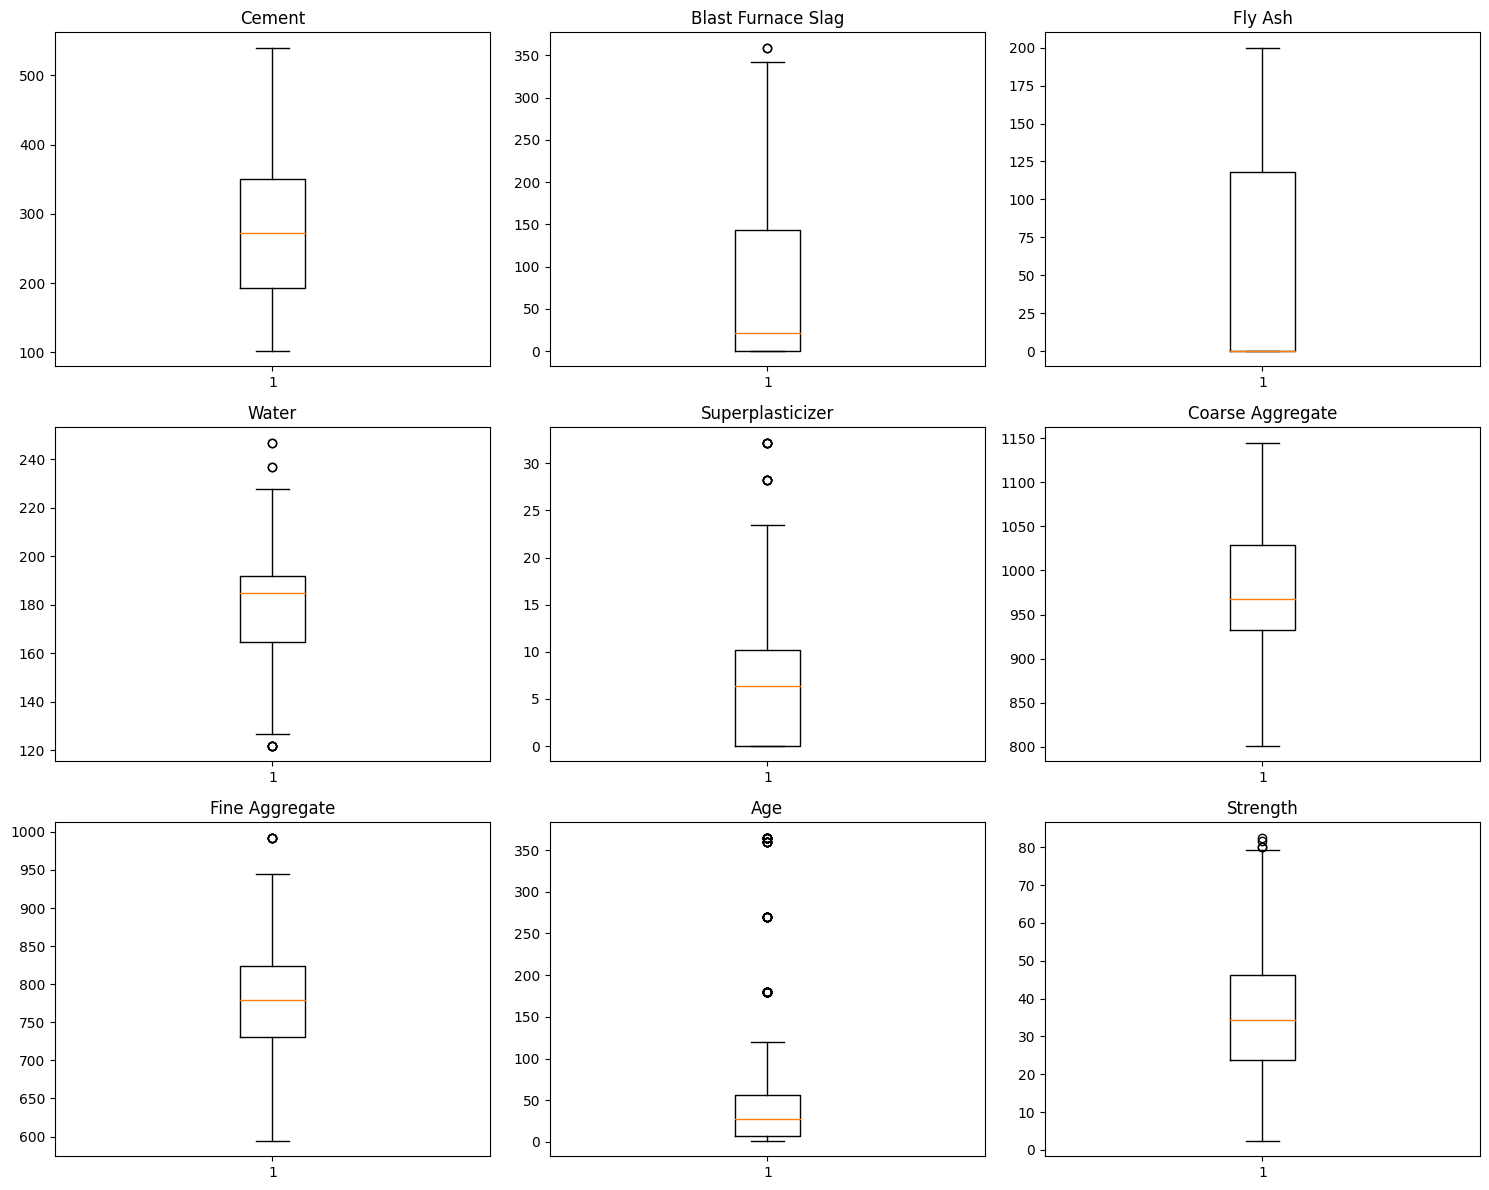

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for index, column in enumerate(df.columns):
    axes[index].boxplot(df[column])
    axes[index].set_title(column)

plt.tight_layout()
plt.show()

In [18]:
#exact duplicate satırları kaldırılır:

df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)
# Beklenen: (1005, 9)

(1005, 9)


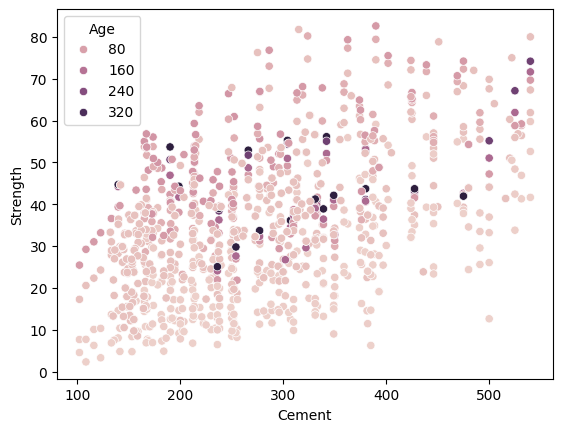

In [19]:
sns.scatterplot(data=df, x="Cement", y="Strength", hue="Age")
plt.show()

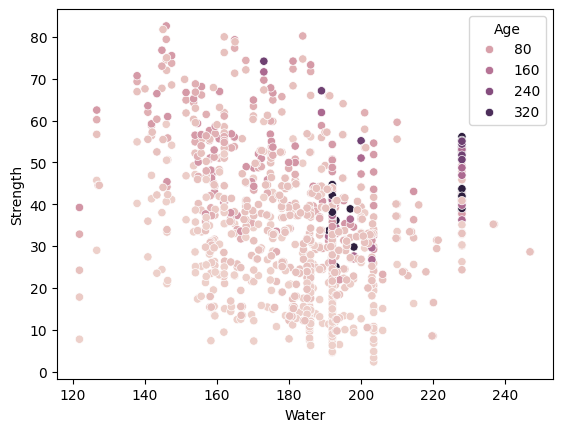

In [20]:
sns.scatterplot(data=df, x="Water", y="Strength", hue="Age")
plt.show()

In [21]:
# dependent feature -> Strength
X = df.drop("Strength", axis = 1)
y = df["Strength"]

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [23]:
from sklearn.tree import DecisionTreeRegressor

In [24]:
# first weak learner
tree_reg1 = DecisionTreeRegressor(max_depth = 3)
tree_reg1.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [25]:
# Residual Error from the first decision tree
y2 = y_train - tree_reg1.predict(X_train)

In [26]:
tree_reg2 = DecisionTreeRegressor(max_depth = 4)
tree_reg2.fit(X_train, y2)

DecisionTreeRegressor(max_depth=4)

In [27]:
# Residual error of the second weak learner
y3 = y2 - tree_reg2.predict(X_train)
y3[:5]

287    7.176595
302    7.543253
847   -4.580237
850   -5.058574
974   -3.551742
Name: Strength, dtype: float64

In [28]:
#third weak learner
tree_reg3 = DecisionTreeRegressor(max_depth = 4)
tree_reg3.fit(X_train, y3)

DecisionTreeRegressor(max_depth=4)

In [29]:
y4 = y3 - tree_reg3.predict(X_train)
y4[:5]

287    8.137332
302    8.503990
847   -3.619501
850   -4.097837
974   -2.591005
Name: Strength, dtype: float64

In [30]:

# let's calculate the final score (we can obviously increase the number of weak learners if we want)
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))

In [31]:
from sklearn.metrics import r2_score

In [32]:
r2_score(y_test, y_pred)

0.7741049684363022

In [34]:
tree_reg4 = DecisionTreeRegressor(max_depth = 4)
tree_reg4.fit(X_train, y4)

DecisionTreeRegressor(max_depth=4)

In [35]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3, tree_reg4))

In [36]:
r2_score(y_test, y_pred)

0.804248253995192

In [37]:
# now let's do this automatically with sklearn

In [38]:
from sklearn.ensemble import GradientBoostingRegressor

In [39]:
gbr = GradientBoostingRegressor(n_estimators=3, max_depth = 3, learning_rate = 0.1)

In [40]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=3)

In [41]:
y_pred = gbr.predict(X_test)
r2_score(y_test, y_pred)

0.2770829151097931

In [42]:
gbr = GradientBoostingRegressor(n_estimators=100, max_depth = 3, learning_rate = 0.1)

In [43]:
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
r2_score(y_test, y_pred)

0.9197492775152065

In [44]:
#hyperparameter tuning

In [45]:
params = {
        "n_estimators" : [100, 150, 200],
        "max_depth" : [3,4,5],
        "loss" : ["squared_error", "absolute_error", "huber", "quantile"],
        "learning_rate" : [0.01, 0.1, 0.5]
}

In [46]:
from sklearn.model_selection import RandomizedSearchCV

In [47]:
rscv = RandomizedSearchCV(estimator=GradientBoostingRegressor(), param_distributions=params, cv=5)

In [48]:
rscv.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber',
                                                 'quantile'],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 150, 200]})

In [49]:
rscv.best_params_

{'n_estimators': 200, 'max_depth': 4, 'loss': 'huber', 'learning_rate': 0.1}

In [50]:
y_pred = rscv.predict(X_test)
r2_score(y_test, y_pred)

0.9477346088995329

In [51]:
# FEATURE ENGİNEERİNG


df["Binder"] = (
    df["Cement"]
    + df["Blast Furnace Slag"]
    + df["Fly Ash"]
)

df["Water_Binder_Ratio"] = (
    df["Water"] / df["Binder"]
)

df["Supplementary_Ratio"] = (
    (df["Blast Furnace Slag"] + df["Fly Ash"])
    / df["Binder"]
)

In [52]:
rscv_2 = RandomizedSearchCV(estimator=GradientBoostingRegressor(), param_distributions=params, cv=5)

In [53]:
rscv_2.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.5],
                                        'loss': ['squared_error',
                                                 'absolute_error', 'huber',
                                                 'quantile'],
                                        'max_depth': [3, 4, 5],
                                        'n_estimators': [100, 150, 200]})

In [54]:
rscv_2.best_params_

{'n_estimators': 200, 'max_depth': 4, 'loss': 'huber', 'learning_rate': 0.5}

In [55]:
y_pred = rscv_2.predict(X_test)
r2_score(y_test, y_pred)

0.9428562258062475